Clean HPPC samples : 2517
HPPC duration (s)  : 1999.3350014090538
Strict increase    : True
Measured current   : -25.0001 to 5.9166 A
PyBaMM current     : -5.9166 to 25.0001 A

MP-DFN PARTICLE DISTRIBUTIONS
Positive mean radius (m) : 2.5e-06
Positive radius SD (m)   : 2.0000000000000003e-06
Positive radius limits   : 1.5e-07 to 1.2e-05
Negative mean radius (m) : 5.86e-06
Negative radius SD (m)   : 1.172e-06
Negative radius limits   : 5.86e-07 to 1.7579999999999998e-05

MP-DFN HPPC VALIDATION
Compared duration (s)    : 1999.3350014090538
Compared samples         : 2517
Net discharge (Ah)       : 0.0011255674762185662
Absolute throughput (Ah) : 0.23043198280013164

Overall RMSE (V)         : 0.028462390611101923
Overall MAE (V)          : 0.021375407578626018
Maximum error (V)        : 0.08070894781003712
Overall bias (V)         : -0.004269906858080214

Rest RMSE / bias (V)     : 0.029256985239950968 / -0.005608583341690957
Discharge RMSE/bias (V)  : 0.02196634554866257 / -0.00380158637

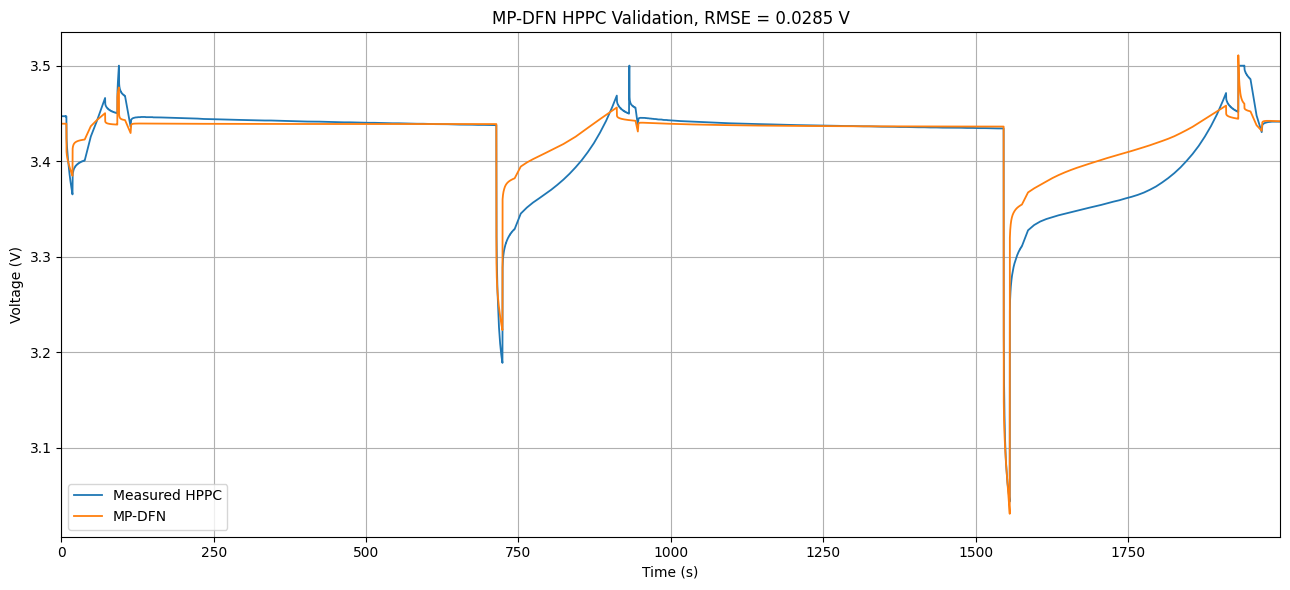

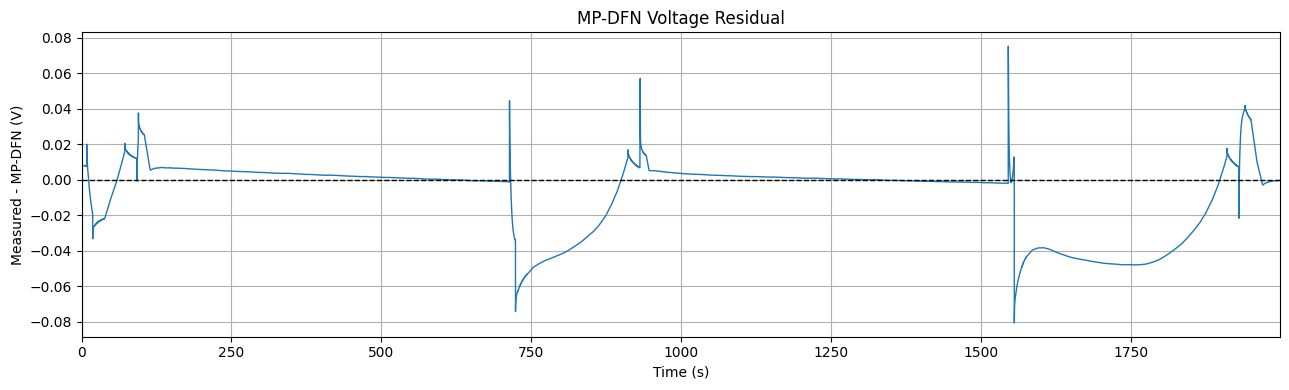

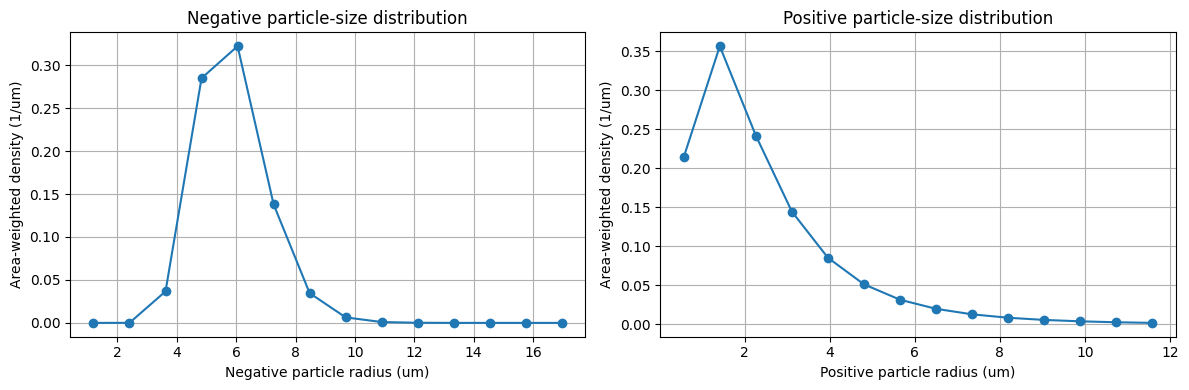

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =====================================================
# USER SETTINGS
# =====================================================

hppc_filename = "HPPC_5458.mat"

t_compare = 2000.0

nominal_capacity_ah = 2.5

theta_n_init = 0.905
theta_p_init = 0.5075

# Single Jokar discharge OCP baseline
ocp_shift = 0.10

negative_thickness = 129e-6
positive_thickness = 171e-6
positive_active_fraction = 0.55

# Mean positive particle radius
positive_radius_mean = 2.5e-6

# Positive PSD standard deviation
# 0.45 means SD = 45% of the mean radius
positive_radius_sd_fraction = 0.8

# Positive PSD limits
positive_radius_min = 0.15e-6
positive_radius_max = 12e-6

# Negative PSD width.
# The mean comes from Prada2013.
negative_radius_sd_fraction = 0.20

positive_diffusivity = 1.0e-13

positive_kinetic_multiplier = 30.0
negative_kinetic_multiplier = 30.0

electrolyte_conductivity_multiplier = 1.6
electrolyte_diffusivity_multiplier = 1.0

contact_resistance = 0.0

model_temperature_kelvin = 296.62

rest_current_threshold = 0.05
discharge_pulse_threshold = 5.0
charge_pulse_threshold = 1.0

# Particle-size discretization.
# Increase R_n and R_p after the model runs successfully.
particle_size_bins = 14

# =====================================================
# JOKAR POSITIVE-ELECTRODE OCP
# =====================================================

aa = 0.5

raw_cathode_axis = np.array([
    1.000000000, 0.998466258, 0.990797546, 0.980061350,
    0.975460123, 0.967791411, 0.957055215, 0.946319018,
    0.924846626, 0.900306748, 0.866564417, 0.829754601,
    0.786809816, 0.737730061, 0.627300613, 0.565950920,
    0.493865031, 0.434049080, 0.394171779, 0.328220859,
    0.256134969, 0.202453988, 0.182515337, 0.156441718,
    0.133435583, 0.108895706, 0.088957055, 0.076687117,
    0.062883436, 0.056748466, 0.049079755, 0.039877301,
    0.032208589, 0.026073620, 0.021472393, 0.015337423,
    0.012269939, 0.009202454, 0.007668712, 0.003067485,
    0.003067480, 0.001533742, 0.001533741, 0.001533740
])

cath_soc = (
    (1.0 - aa)
    + aa * (1.0 - raw_cathode_axis)
)

cath_ocv = np.array([
    3.597674419, 3.552330932, 3.465148381, 3.402395135,
    3.391946069, 3.381507704, 3.371080040, 3.360652376,
    3.353750535, 3.350347767, 3.346977101, 3.340128763,
    3.336790198, 3.329984663, 3.312928021, 3.309653660,
    3.302928378, 3.296160294, 3.289322657, 3.282575974,
    3.268873948, 3.251619347, 3.241223784, 3.230849622,
    3.220464760, 3.210085248, 3.196201313, 3.175313882,
    3.136989942, 3.112592738, 3.081224140, 3.039395777,
    2.997562063, 2.948746255, 2.906901840, 2.830179056,
    2.774375803, 2.718572550, 2.662763946, 2.582547439,
    2.519756741, 2.449994650, 2.380227208, 2.334878371
])

cath_ocv = cath_ocv + ocp_shift

# Sort and remove nearly duplicated stoichiometry values
ocp_order = np.argsort(
    cath_soc,
    kind="stable"
)

cath_soc = cath_soc[ocp_order]
cath_ocv = cath_ocv[ocp_order]

ocp_keep = np.concatenate((
    [True],
    np.diff(cath_soc) > 1e-6
))

cath_soc = cath_soc[ocp_keep]
cath_ocv = cath_ocv[ocp_keep]

# Extend to [0, 1] with constant endpoint extension
sto_grid = np.linspace(
    0.0,
    1.0,
    1000
)

ocv_grid = np.interp(
    sto_grid,
    cath_soc,
    cath_ocv,
    left=cath_ocv[0],
    right=cath_ocv[-1]
)

def custom_positive_ocp(sto):
    return pybamm.Interpolant(
        sto_grid,
        ocv_grid,
        sto,
        interpolator="linear"
    )

# =====================================================
# LOAD AND CLEAN HPPC DATA
# =====================================================

hppc_data = loadmat(
    hppc_filename,
    squeeze_me=True,
    struct_as_record=False
)

meas = hppc_data["meas"]

time_raw = np.asarray(
    meas.Time,
    dtype=float
).reshape(-1)

current_raw = np.asarray(
    meas.Current,
    dtype=float
).reshape(-1)

voltage_raw = np.asarray(
    meas.Voltage,
    dtype=float
).reshape(-1)

number_raw = min(
    len(time_raw),
    len(current_raw),
    len(voltage_raw)
)

time_raw = time_raw[:number_raw]
current_raw = current_raw[:number_raw]
voltage_raw = voltage_raw[:number_raw]

finite_mask = (
    np.isfinite(time_raw)
    & np.isfinite(current_raw)
    & np.isfinite(voltage_raw)
)

time_raw = time_raw[finite_mask]
current_raw = current_raw[finite_mask]
voltage_raw = voltage_raw[finite_mask]

time_raw = (
    time_raw
    - time_raw[0]
)

duration_mask = (
    (time_raw >= 0.0)
    & (time_raw <= t_compare)
)

time_raw = time_raw[duration_mask]
current_raw = current_raw[duration_mask]
voltage_raw = voltage_raw[duration_mask]

# Sort timestamps
time_order = np.argsort(
    time_raw,
    kind="stable"
)

time_sorted = time_raw[time_order]
current_sorted = current_raw[time_order]
voltage_sorted = voltage_raw[time_order]

# Keep the final value at every duplicated timestamp
_, reverse_unique_index = np.unique(
    time_sorted[::-1],
    return_index=True
)

last_index = (
    len(time_sorted)
    - 1
    - reverse_unique_index
)

last_index = np.sort(
    last_index
)

time_exp = time_sorted[last_index]
current_measured = current_sorted[last_index]
voltage_exp = voltage_sorted[last_index]

# Final strict-increase protection
strict_mask = np.concatenate((
    [True],
    np.diff(time_exp) > 0.0
))

time_exp = time_exp[strict_mask]
current_measured = current_measured[strict_mask]
voltage_exp = voltage_exp[strict_mask]

if len(time_exp) < 2:
    raise ValueError(
        "Fewer than two unique HPPC timestamps remain."
    )

if not np.all(np.diff(time_exp) > 0.0):
    raise ValueError(
        "HPPC time vector is not strictly increasing."
    )

# Experimental sign is opposite to PyBaMM convention
current_pybamm = (
    -current_measured
)

hppc_current = pybamm.Interpolant(
    time_exp,
    current_pybamm,
    pybamm.t,
    interpolator="linear"
)

print("Clean HPPC samples :", len(time_exp))
print("HPPC duration (s)  :", time_exp[-1])
print(
    "Strict increase    :",
    bool(np.all(np.diff(time_exp) > 0.0))
)
print(
    "Measured current   :",
    current_measured.min(),
    "to",
    current_measured.max(),
    "A"
)
print(
    "PyBaMM current     :",
    current_pybamm.min(),
    "to",
    current_pybamm.max(),
    "A"
)

# =====================================================
# BASE PRADA2013 PARAMETER SET
# =====================================================

params = pybamm.ParameterValues(
    "Prada2013"
)

c_n_max = params[
    "Maximum concentration in negative electrode [mol.m-3]"
]

c_p_max = params[
    "Maximum concentration in positive electrode [mol.m-3]"
]

negative_radius_mean = params[
    "Negative particle radius [m]"
]

# Store original functions before overriding
original_positive_j0 = params[
    "Positive electrode exchange-current density [A.m-2]"
]

original_negative_j0 = params[
    "Negative electrode exchange-current density [A.m-2]"
]

original_electrolyte_conductivity = params[
    "Electrolyte conductivity [S.m-1]"
]

original_electrolyte_diffusivity = params[
    "Electrolyte diffusivity [m2.s-1]"
]

# =====================================================
# CALIBRATED KINETIC FUNCTIONS
# =====================================================

def scaled_positive_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):
    return (
        positive_kinetic_multiplier
        * original_positive_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

def scaled_negative_exchange_current_density(
    c_e,
    c_s_surf,
    c_s_max,
    temperature
):
    return (
        negative_kinetic_multiplier
        * original_negative_j0(
            c_e,
            c_s_surf,
            c_s_max,
            temperature
        )
    )

# =====================================================
# CALIBRATED ELECTROLYTE FUNCTIONS
# =====================================================

def scaled_electrolyte_conductivity(
    c_e,
    temperature
):
    return (
        electrolyte_conductivity_multiplier
        * original_electrolyte_conductivity(
            c_e,
            temperature
        )
    )

def scaled_electrolyte_diffusivity(
    c_e,
    temperature
):
    return (
        electrolyte_diffusivity_multiplier
        * original_electrolyte_diffusivity(
            c_e,
            temperature
        )
    )

# =====================================================
# APPLY BASE CALIBRATED PARAMETERS
# =====================================================

params.update({
    "Nominal cell capacity [A.h]":
        nominal_capacity_ah,

    "Initial temperature [K]":
        model_temperature_kelvin,

    "Ambient temperature [K]":
        model_temperature_kelvin,

    "Positive electrode OCP [V]":
        custom_positive_ocp,

    "Initial concentration in negative electrode [mol.m-3]":
        theta_n_init * c_n_max,

    "Initial concentration in positive electrode [mol.m-3]":
        theta_p_init * c_p_max,

    "Negative electrode thickness [m]":
        negative_thickness,

    "Positive electrode thickness [m]":
        positive_thickness,

    "Positive electrode active material volume fraction":
        positive_active_fraction,

    "Positive particle radius [m]":
        positive_radius_mean,

    "Positive electrode diffusivity [m2.s-1]":
        positive_diffusivity,

    "Positive electrode exchange-current density [A.m-2]":
        scaled_positive_exchange_current_density,

    "Negative electrode exchange-current density [A.m-2]":
        scaled_negative_exchange_current_density,

    "Electrolyte conductivity [S.m-1]":
        scaled_electrolyte_conductivity,

    "Electrolyte diffusivity [m2.s-1]":
        scaled_electrolyte_diffusivity,

    "Current function [A]":
        hppc_current,

    "Contact resistance [Ohm]":
        contact_resistance
})

# =====================================================
# ADD DEFAULT LOGNORMAL SIZE-DISTRIBUTION PARAMETERS
# =====================================================

if not hasattr(
    pybamm,
    "get_size_distribution_parameters"
):
    raise AttributeError(
        "This PyBaMM version does not provide "
        "get_size_distribution_parameters(). "
        "Upgrade PyBaMM to a version supporting MP-DFN."
    )

params = pybamm.get_size_distribution_parameters(
    params
)

# =====================================================
# CUSTOM PARTICLE-SIZE DISTRIBUTIONS
# =====================================================

positive_radius_sd = (
    positive_radius_sd_fraction
    * positive_radius_mean
)

negative_radius_sd = (
    negative_radius_sd_fraction
    * negative_radius_mean
)

negative_radius_min = max(
    0.10 * negative_radius_mean,
    1e-9
)

negative_radius_max = (
    3.0 * negative_radius_mean
)

# Area-weighted lognormal distributions.
# Each function must accept only particle radius R.
def positive_area_weighted_psd(radius):
    return pybamm.lognormal(
        radius,
        positive_radius_mean,
        positive_radius_sd
    )

def negative_area_weighted_psd(radius):
    return pybamm.lognormal(
        radius,
        negative_radius_mean,
        negative_radius_sd
    )

params.update({
    "Positive minimum particle radius [m]":
        positive_radius_min,

    "Positive maximum particle radius [m]":
        positive_radius_max,

    "Positive area-weighted particle-size distribution [m-1]":
        positive_area_weighted_psd,

    "Negative minimum particle radius [m]":
        negative_radius_min,

    "Negative maximum particle radius [m]":
        negative_radius_max,

    "Negative area-weighted particle-size distribution [m-1]":
        negative_area_weighted_psd
})

print()
print("================================")
print("MP-DFN PARTICLE DISTRIBUTIONS")
print("================================")
print(
    "Positive mean radius (m) :",
    positive_radius_mean
)
print(
    "Positive radius SD (m)   :",
    positive_radius_sd
)
print(
    "Positive radius limits   :",
    positive_radius_min,
    "to",
    positive_radius_max
)
print(
    "Negative mean radius (m) :",
    negative_radius_mean
)
print(
    "Negative radius SD (m)   :",
    negative_radius_sd
)
print(
    "Negative radius limits   :",
    negative_radius_min,
    "to",
    negative_radius_max
)

# =====================================================
# BUILD MP-DFN MODEL
# =====================================================

model = pybamm.lithium_ion.DFN(
    options={
        "particle size": "distribution",
        "contact resistance": "true",
        "thermal": "isothermal"
    },
    name="Calibrated MP-DFN"
)

# Keep mesh small for the first run.
# R_n and R_p control the number of particle-size bins.
var_pts = {
    "x_n": 12,
    "x_s": 8,
    "x_p": 12,
    "r_n": 10,
    "r_p": 10,
    "R_n": particle_size_bins,
    "R_p": particle_size_bins
}

solver = pybamm.CasadiSolver(
    mode="safe",
    dt_max=1.0,
    return_solution_if_failed_early=True
)

simulation = pybamm.Simulation(
    model,
    parameter_values=params,
    solver=solver,
    var_pts=var_pts
)

# =====================================================
# RUN MP-DFN
# =====================================================

solution = simulation.solve(
    t_eval=time_exp
)

time_model = np.asarray(
    solution["Time [s]"].entries,
    dtype=float
).reshape(-1)

voltage_model = np.asarray(
    solution["Terminal voltage [V]"].entries,
    dtype=float
).reshape(-1)

if len(time_model) < 2:
    raise RuntimeError(
        "MP-DFN returned fewer than two time points."
    )

# =====================================================
# VALID COMPARISON WINDOW
# =====================================================

t_valid_end = min(
    float(time_exp[-1]),
    float(time_model[-1]),
    t_compare
)

valid_mask = (
    time_exp
    <= t_valid_end
)

time_valid = time_exp[
    valid_mask
]

current_valid = current_pybamm[
    valid_mask
]

voltage_measured_valid = voltage_exp[
    valid_mask
]

voltage_simulated_valid = np.interp(
    time_valid,
    time_model,
    voltage_model
)

voltage_error = (
    voltage_measured_valid
    - voltage_simulated_valid
)

# =====================================================
# METRICS
# =====================================================

overall_rmse = float(
    np.sqrt(
        np.mean(
            voltage_error ** 2
        )
    )
)

overall_mae = float(
    np.mean(
        np.abs(
            voltage_error
        )
    )
)

maximum_error = float(
    np.max(
        np.abs(
            voltage_error
        )
    )
)

overall_bias = float(
    np.mean(
        voltage_error
    )
)

rest_mask = (
    np.abs(current_valid)
    < rest_current_threshold
)

discharge_mask = (
    current_valid
    > discharge_pulse_threshold
)

charge_mask = (
    current_valid
    < -charge_pulse_threshold
)

intermediate_mask = (
    ~rest_mask
    & ~discharge_mask
    & ~charge_mask
)

def masked_rmse(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.sqrt(
            np.mean(
                voltage_error[mask] ** 2
            )
        )
    )

def masked_bias(mask):

    if not np.any(mask):
        return np.nan

    return float(
        np.mean(
            voltage_error[mask]
        )
    )

rest_rmse = masked_rmse(
    rest_mask
)

rest_bias = masked_bias(
    rest_mask
)

discharge_rmse = masked_rmse(
    discharge_mask
)

discharge_bias = masked_bias(
    discharge_mask
)

charge_rmse = masked_rmse(
    charge_mask
)

charge_bias = masked_bias(
    charge_mask
)

intermediate_rmse = masked_rmse(
    intermediate_mask
)

intermediate_bias = masked_bias(
    intermediate_mask
)

# =====================================================
# THROUGHPUT
# =====================================================

integrator = (
    np.trapezoid
    if hasattr(np, "trapezoid")
    else np.trapz
)

net_discharge_ah = float(
    integrator(
        current_valid,
        time_valid
    ) / 3600.0
)

absolute_throughput_ah = float(
    integrator(
        np.abs(current_valid),
        time_valid
    ) / 3600.0
)

# =====================================================
# PRINT RESULTS
# =====================================================

print()
print("================================")
print("MP-DFN HPPC VALIDATION")
print("================================")
print(
    "Compared duration (s)    :",
    t_valid_end
)
print(
    "Compared samples         :",
    len(time_valid)
)
print(
    "Net discharge (Ah)       :",
    net_discharge_ah
)
print(
    "Absolute throughput (Ah) :",
    absolute_throughput_ah
)
print()
print(
    "Overall RMSE (V)         :",
    overall_rmse
)
print(
    "Overall MAE (V)          :",
    overall_mae
)
print(
    "Maximum error (V)        :",
    maximum_error
)
print(
    "Overall bias (V)         :",
    overall_bias
)
print()
print(
    "Rest RMSE / bias (V)     :",
    rest_rmse,
    "/",
    rest_bias
)
print(
    "Discharge RMSE/bias (V)  :",
    discharge_rmse,
    "/",
    discharge_bias
)
print(
    "Charge RMSE / bias (V)   :",
    charge_rmse,
    "/",
    charge_bias
)
print(
    "Intermediate RMSE/bias   :",
    intermediate_rmse,
    "/",
    intermediate_bias
)

# =====================================================
# VOLTAGE COMPARISON
# =====================================================

plt.figure(figsize=(13, 6))

plt.plot(
    time_valid,
    voltage_measured_valid,
    linewidth=1.3,
    label="Measured HPPC"
)

plt.plot(
    time_model,
    voltage_model,
    linewidth=1.3,
    label="MP-DFN"
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")

plt.title(
    f"MP-DFN HPPC Validation, "
    f"RMSE = {overall_rmse:.4f} V"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# VOLTAGE RESIDUAL
# =====================================================

plt.figure(figsize=(13, 4))

plt.plot(
    time_valid,
    voltage_error,
    linewidth=1.0
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0
)

plt.xlim(
    0,
    t_valid_end
)

plt.xlabel("Time (s)")
plt.ylabel("Measured - MP-DFN (V)")
plt.title("MP-DFN Voltage Residual")

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================================
# PLOT DISCRETIZED PARTICLE-SIZE DISTRIBUTIONS
# =====================================================

try:
    positive_sizes = solution[
        "Positive particle sizes [m]"
    ].entries[:, 0, 0]

    negative_sizes = solution[
        "Negative particle sizes [m]"
    ].entries[:, 0, 0]

    positive_psd = solution[
        "X-averaged positive area-weighted "
        "particle-size distribution [m-1]"
    ].entries[:, 0]

    negative_psd = solution[
        "X-averaged negative area-weighted "
        "particle-size distribution [m-1]"
    ].entries[:, 0]

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    axes[0].plot(
        negative_sizes * 1e6,
        negative_psd * 1e-6,
        marker="o"
    )

    axes[0].set_xlabel(
        "Negative particle radius (um)"
    )

    axes[0].set_ylabel(
        "Area-weighted density (1/um)"
    )

    axes[0].set_title(
        "Negative particle-size distribution"
    )

    axes[0].grid(True)

    axes[1].plot(
        positive_sizes * 1e6,
        positive_psd * 1e-6,
        marker="o"
    )

    axes[1].set_xlabel(
        "Positive particle radius (um)"
    )

    axes[1].set_ylabel(
        "Area-weighted density (1/um)"
    )

    axes[1].set_title(
        "Positive particle-size distribution"
    )

    axes[1].grid(True)

    figure.tight_layout()
    plt.show()

except Exception as distribution_error:

    print()
    print(
        "Particle-size distribution plot skipped:"
    )
    print(distribution_error)